In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import csr_matrix
from sklearn.decomposition import TruncatedSVD
import joblib

In [2]:
CLEAN_TMDB_FILE_PATH = "../datasets/clean/tmdb-movies/TMDB_movie_dataset_v11.csv"
CLEAN_MOVIELENS_RATINGS_PATH = "../datasets/clean/ml-32m/ratings.csv"

ML_API_TF_IDF_MATRIX_PATH = "../../ml-api/model/tf_idf_matrix.pkl"

In [3]:
tmdb = pd.read_csv(CLEAN_TMDB_FILE_PATH)
ratings = pd.read_csv(CLEAN_MOVIELENS_RATINGS_PATH)

In [4]:
tmdb.head()

,id,title,overview,genres,keywords,vote_average,vote_count,popularity,popularity_log,content
0,27205,Inception,"Cobb, a skilled thief who commits corporate es...","Action, Science Fiction, Adventure","rescue, mission, dream, airplane, paris, franc...",8.364,34495,83.952,4.442086,"Cobb, a skilled thief who commits corporate es..."
1,157336,Interstellar,The adventures of a group of explorers who mak...,"Adventure, Drama, Science Fiction","rescue, future, spacecraft, race against time,...",8.417,32571,140.241,4.950468,The adventures of a group of explorers who mak...
2,155,The Dark Knight,Batman raises the stakes in his war on crime. ...,"Drama, Action, Crime, Thriller","joker, sadism, chaos, secret identity, crime f...",8.512,30619,130.643,4.880094,Batman raises the stakes in his war on crime. ...
3,19995,Avatar,"In the 22nd century, a paraplegic Marine is di...","Action, Adventure, Fantasy, Science Fiction","future, society, culture clash, space travel, ...",7.573,29815,79.932,4.393609,"In the 22nd century, a paraplegic Marine is di..."
4,24428,The Avengers,When an unexpected enemy emerges and threatens...,"Science Fiction, Action, Adventure","new york city, superhero, shield, based on com...",7.710,29166,98.082,4.595948,When an unexpected enemy emerges and threatens...


In [5]:
tmdb.info()

<class 'pandas.DataFrame'>
RangeIndex: 37972 entries, 0 to 37971
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              37972 non-null  int64  
 1   title           37972 non-null  str    
 2   overview        37725 non-null  str    
 3   genres          37883 non-null  str    
 4   keywords        31050 non-null  str    
 5   vote_average    37972 non-null  float64
 6   vote_count      37972 non-null  int64  
 7   popularity      37972 non-null  float64
 8   popularity_log  37972 non-null  float64
 9   content         37972 non-null  str    
dtypes: float64(3), int64(2), str(5)
memory usage: 2.9 MB


In [6]:
ratings.head()

,userId,rating,movieId,tmdbId
0,1,4.0,17,4584
1,1,1.0,25,451
2,1,2.0,29,902
3,1,5.0,30,37557
4,1,5.0,32,63


In [7]:
ratings.info()

<class 'pandas.DataFrame'>
RangeIndex: 31916931 entries, 0 to 31916930
Data columns (total 4 columns):
 #   Column   Dtype  
---  ------   -----  
 0   userId   int64  
 1   rating   float64
 2   movieId  int64  
 3   tmdbId   int64  
dtypes: float64(1), int64(3)
memory usage: 974.0 MB


In [8]:
tmdb_id_to_index = pd.Series(tmdb.index, index=tmdb["id"]).to_dict()
ratings["rating"] = ratings["rating"] - ratings["rating"].mean()

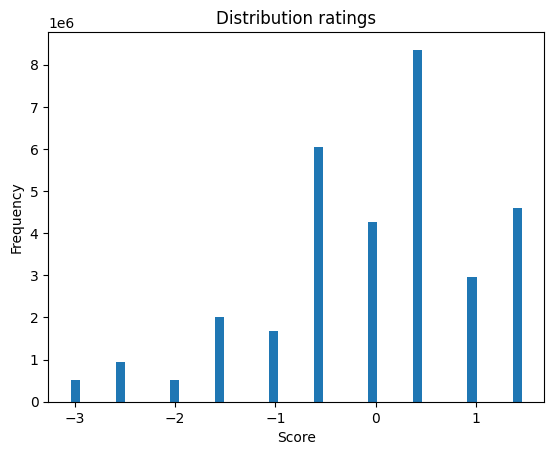

In [9]:
plt.hist(ratings["rating"], bins=50)
plt.title("Distribution ratings")
plt.xlabel("Score")
plt.ylabel("Frequency")
plt.show()

In [ ]:
print("min:", ratings["rating"].min())
print("max:", ratings["rating"].max())
print("mean:", ratings["rating"].mean())
print("std:", ratings["rating"].std())
print(np.percentile(ratings["rating"], [0, 25, 50, 75, 100]))

min: -3.0419925869439015
max: 1.4580074130560985
mean: -2.756102319345103e-16
std: 1.0581912389528363
[-3.04199259 -0.54199259 -0.04199259  0.45800741  1.45800741]


In [125]:
def find_in_dataset_by_substring(movie_names):
    found = []
    for movie_name in movie_names:
        results = tmdb[tmdb["title"].str.contains(movie_name, case=False, na=False)]
        haa = results.sort_values(by="popularity", ascending=False)[["id", "title"]]
        found.append(haa.values.tolist())
    return found

def find_in_dataset_by_id(movie_id):
    return tmdb[tmdb["id"] == movie_id]["title"].values[0]

def print_ratings_dict(ratings_dict: dict[int, int]):
    for id, rating in ratings_dict.items():
        print(f"id: {id}, name: {find_in_dataset_by_id(id)}, rating: {rating}")

In [126]:
find_in_dataset_by_substring(["justice", "batman", "superman", "flash", "lantern", "steel", "watchmen", "joker"])

[[[1003581, 'Justice League: Warworld'],
  [791373, "Zack Snyder's Justice League"],
  [141052, 'Justice League'],
  [209112, 'Batman v Superman: Dawn of Justice'],
  [297556, 'Justice League: Throne of Atlantis'],
  [14362, 'Out for Justice'],
  [183011, 'Justice League: The Flashpoint Paradox'],
  [997776, 'Justice League x RWBY: Super Heroes & Huntsmen, Part One'],
  [618344, 'Justice League Dark: Apokolips War'],
  [831405, 'Injustice'],
  [736069, 'Justice Society: World War II'],
  [663870, 'Riders of Justice'],
  [382512, 'LEGO DC Comics Super Heroes: Justice League: Cosmic Clash'],
  [150213, 'Pokémon the Movie: Kyurem vs. the Sword of Justice'],
  [323027, 'Justice League: Gods and Monsters'],
  [379291, 'Justice League vs. Teen Titans'],
  [14011, 'Justice League: The New Frontier'],
  [217993, 'Justice League: War'],
  [76589, 'Justice League: Doom'],
  [30061, 'Justice League: Crisis on Two Earths'],
  [17443, '...And Justice for All'],
  [408220, 'Justice League Dark'],
  

In [127]:
find_in_dataset_by_id(791373)

"Zack Snyder's Justice League"

In [128]:
marvel_fan_rd = {
  569094: 4.5,
  634649: 4,
  271110: 3,
  1771: 4,
  10138: 4.5,
  1724: 3.5,
  26881: 4,
  299536: 5,
  9320: 4.5
}

print_ratings_dict(marvel_fan_rd)
print()
print()
print()

marvel_fan_dc_hater_rd = {
  569094: 4.5,
  634649: 4,
  271110: 3,
  1771: 4,
  10138: 4.5,
  1724: 3.5,
  26881: 4,
  299536: 5,
  9320: 4.5,
  141052: 1,
  209112: 0,
  414906: 2.5,
  272: 1.4,
  1924: 1,
  298618: 0.7,
  44912: 0,
  49521: 1.8,
  13183: 0.3,
  475557: 3
}

print_ratings_dict(marvel_fan_dc_hater_rd)

id: 569094, name: Spider-Man: Across the Spider-Verse, rating: 4.5
id: 634649, name: Spider-Man: No Way Home, rating: 4
id: 271110, name: Captain America: Civil War, rating: 3
id: 1771, name: Captain America: The First Avenger, rating: 4
id: 10138, name: Iron Man 2, rating: 4.5
id: 1724, name: The Incredible Hulk, rating: 3.5
id: 26881, name: The Incredible Hulk Returns, rating: 4
id: 299536, name: Avengers: Infinity War, rating: 5
id: 9320, name: The Avengers, rating: 4.5



id: 569094, name: Spider-Man: Across the Spider-Verse, rating: 4.5
id: 634649, name: Spider-Man: No Way Home, rating: 4
id: 271110, name: Captain America: Civil War, rating: 3
id: 1771, name: Captain America: The First Avenger, rating: 4
id: 10138, name: Iron Man 2, rating: 4.5
id: 1724, name: The Incredible Hulk, rating: 3.5
id: 26881, name: The Incredible Hulk Returns, rating: 4
id: 299536, name: Avengers: Infinity War, rating: 5
id: 9320, name: The Avengers, rating: 4.5
id: 141052, name: Justice League, rating:

Content based filtering

In [129]:
tfidf = TfidfVectorizer(
    max_features=50000,
    stop_words="english"
)

tfidf_matrix = tfidf.fit_transform(tmdb["content"])

In [130]:
def build_user_profile_content(ratings_dict):
    vectors = []
    weights = []

    for tmdb_id, rating in ratings_dict.items():
        if tmdb_id in tmdb_id_to_index:
            idx = tmdb_id_to_index[tmdb_id]
            vectors.append(tfidf_matrix[idx].toarray()[0])
            weights.append(rating + 3.5)

    vectors = np.array(vectors)
    weights = np.array(weights)

    # vážený průměr
    user_profile = np.average(vectors, axis=0, weights=weights)
    user_profile = user_profile.reshape(1, -1)

    return user_profile

In [131]:
def build_user_profile_content(ratings_dict):
    vectors = []
    weights = []

    for tmdb_id, rating in ratings_dict.items():
        if tmdb_id in tmdb_id_to_index:
            idx = tmdb_id_to_index[tmdb_id]
            vectors.append(tfidf_matrix[idx].toarray()[0])
            weights.append(rating - 2.5)

    vectors = np.array(vectors)
    weights = np.array(weights)

    user_profile = np.sum(vectors * weights[:, np.newaxis], axis=0)
    user_profile = user_profile.reshape(1, -1)

    return user_profile

In [132]:
from sklearn.metrics.pairwise import cosine_similarity

def recommend_content(user_vector, top_k=20):
    sims = cosine_similarity(user_vector, tfidf_matrix).flatten()
    weighted_sims = sims * tmdb["popularity_log"].values
    top_idx = weighted_sims.argsort()[-top_k:][::-1]
    return tmdb.iloc[top_idx][["id", "title", "vote_average", "popularity"]]

def find_recommended_content(user_vector, movie_id=1): # top_k tu asi nepotřebujeme, když hledáš konkrétní ID
    sims = cosine_similarity(user_vector, tfidf_matrix).flatten()
    weighted_sims = sims * tmdb["popularity_log"].values
    results = tmdb[["id", "title", "vote_average", "popularity"]].copy()
    results["match_score"] = weighted_sims

    # 1. Přidáme absolutní pořadí (1 = úplně nejlepší film pro tohoto uživatele)
    # ascending=False znamená, že nejvyšší skóre dostane rank 1
    results["rank"] = results["match_score"].rank(ascending=False).astype(int)
    
    # 2. Přidáme percentil (např. 99.5 znamená, že film je lepší než 99.5 % datasetu)
    # pct=True nám vrátí hodnoty od 0 do 1, takže to vynásobíme 100
    results["percentile"] = results["match_score"].rank(pct=True) * 100

    return results[results["id"] == movie_id]

def analyze_recommended_content(user_vector):
    sims = cosine_similarity(user_vector, tfidf_matrix).flatten()
    weighted_sims = sims * tmdb["popularity_log"].values
    
    results = tmdb[["id", "title", "vote_average", "popularity"]].copy()
    results["match_score"] = weighted_sims

    # --- 1. Základní statistiky a percentily ---
    print("=== STATISTIKY MATCH SCORE ===")
    stats = results["match_score"].describe(percentiles=[0.5, 0.75, 0.90, 0.95, 0.99])
    print(stats)
    print("\n")

    # --- 2. Analýza distribuce (Kladné vs Záporné) ---
    print("=== DISTRIBUCE SKÓRE ===")
    kladne = (results["match_score"] > 0).sum()
    zaporne = (results["match_score"] < 0).sum()
    nuly = (results["match_score"] == 0).sum()
    
    print(f"Filmy s kladným skóre (kandidáti na doporučení): {kladne}")
    print(f"Filmy se záporným skóre (aktivně penalizované):  {zaporne}")
    print(f"Filmy s nulovým skóre (žádná shoda v textu):    {nuly}")

In [134]:
marvel_fan = build_user_profile_content(marvel_fan_rd)

#print(recommend_content(marvel_fan))
print(find_recommended_content(marvel_fan, movie_id = 791373))
print(find_recommended_content(marvel_fan, movie_id = 569094))
analyze_recommended_content(marvel_fan)

print()
print()
print()
print()

marvel_fan_dc_hater = build_user_profile_content(marvel_fan_dc_hater_rd)

#print(recommend_content(marvel_fan_dc_hater))
print(find_recommended_content(marvel_fan_dc_hater, movie_id = 791373))
print(find_recommended_content(marvel_fan_dc_hater, movie_id = 569094))
analyze_recommended_content(marvel_fan_dc_hater)

         id                         title  vote_average  popularity  \
328  791373  Zack Snyder's Justice League          8.19      130.69   

     match_score  rank  percentile  
328     1.355489    22   99.944696  
         id                                title  vote_average  popularity  \
952  569094  Spider-Man: Across the Spider-Verse         8.442     512.336   

     match_score  rank  percentile  
952     3.403346     1       100.0  
=== STATISTIKY MATCH SCORE ===
count    37972.000000
mean         0.058738
std          0.088360
min          0.000000
50%          0.036811
75%          0.071787
90%          0.126252
95%          0.175441
99%          0.364546
max          3.403346
Name: match_score, dtype: float64


=== DISTRIBUCE SKÓRE ===
Filmy s kladným skóre (kandidáti na doporučení): 36742
Filmy se záporným skóre (aktivně penalizované):  0
Filmy s nulovým skóre (žádná shoda v textu):    1230




         id                         title  vote_average  popularity  \
328  7

Saving this abhorrent "progress"

In [32]:
joblib.dump(tfidf_matrix, ML_API_TF_IDF_MATRIX_PATH)

['../../ml-api/model/tf_idf_matrix.pkl']